<p style="text-align:center">
    <a href="https://www.ict.mahidol.ac.th/en/" target="_blank">
    <img src="https://www3.ict.mahidol.ac.th/ICTSurveysV2/Content/image/MUICT2.png" width="400" alt="Faculty of ICT">
    </a>
</p>

# Lab 01: TinyML Deployment with ExecuTorch

### Signal Data Machine Learning for Always-on tiny (NPU/NDP/MCU) Devices using XNNPACK Backend:

---

This tutorial provides a hands-on introduction to TinyML using a small sequence model, for (time-based) sensor signal classification.
We cover model measurements for deployment, and environmental metrics.


<div style="border: 2px solid blue;
padding: 15px;
border-radius: 8px;
background-color: #fffafa;
color: #333;">

### 📝 Lab Tutorial Steps:

It covers the key tasks:

1) Exporting a `PyTorch` model as `ExecuTorch`, for edge hardware and embedded systems deployment.
2) Measure PyTorch models and **lowered** (`ExecutTorch`) models.
  - *i.e. importance of **lowering** (compliation types) on inference time performance.*
3) Benchmarking the model and evaluating cross-hardware performance, including for its **in-memory feasibilty** and what is the impact on its **carbon footprint**?
  - *(on which hardware can it run?, how long will take to run?, and should the model be quantized to improve performance?)*

<br>

No prior deep learning expertise is assumed.

<br>

### Learning Objectives
By the end of this lab, you will be able to:
1.  **Export** a PyTorch `nn.Module` to the **ExecuTorch (.pte)** format using the `torch.export` workflow.
2.  **Compare** the trade-offs between standard PyTorch and ExecuTorch in terms of **memory footprint**, **binary size**, and **inference latency**.
3.  **Evaluate** model feasibility across a range of **edge hardware** (*from MCUs, NPUs to Mobile Smartphones to NVIDIA GPU Servers*) using standardized performance metrics.
4.  **Understand** the role of **XNNPACK** as a CPU-based backend for efficient inference on mobile and embedded systems.


<br>

> **Important:**
> - Select the `T4 GPU runtime` within in `Google Colab`, before you start.

</div>


## 1 Installing ExecuTorch and Initial Testing:

This notebook uses the prebuilt `executorch` pip package to export and run an XNNPACK-delegated model. This shows that it's possible to do so without needing to clone the repo and install from source, simplifying the steps currently at https://pytorch.org/executorch/stable/getting-started-setup.html.

Note that this will only work if the model is compatible with the operators and backends linked into the `executorch>=0.2.0` package: i.e., it uses the core ATen operator set, and may use the XNNPACK backend. But this example doesn't support custom operators or other backends.

Install the prebuilt executorch pip package.

NOTE: You may see the message ERROR: pip's dependency resolver ... for packages like torchaudio and torchtext, but it won't affect this demo.

In [ ]:
!uv pip install executorch

# Instead of 1.0.0, use the latest version in https://pypi.org/project/executorch/#history

Demonstrate that the packages are imported successfully.

In [ ]:
from executorch import version
version.__version__

In [ ]:
import torch
torch.__version__
# executorch pip package uses torch as dependency

Demonstrate that the native pybindings module imports successfully, and provides basic operators.

Pybindings are great for doing testing and prototyping. Ultimately, you'll need to write the executorch runtime integration in C++ during productionization.

In [ ]:
from executorch.runtime import Runtime

runtime = Runtime.get()
operator_names = runtime.operator_registry.operator_names
print(len(operator_names))
print(next(iter(operator_names)))


## 2 Concepts: TinyML on Embedded Systems: *Example of Sensor Signal Classification*

In TinyML, we often process **sensor sequence data** (accelerometers, gas sensors, or temperature probes) rather than high-resolution images.


These tasks require small-scale sequence-based models. Transformers are perfect if we have large memory capacity and many cores;
so for TinyML sequence-based tasks we return to efficient lightweight DL models, that require less memory and computation per inference.



### 2.1 Dataset & Applied Case: Industrial Fire and Anomaly Detection
For this lab, we consider a model designed for a (10 x 22 x 8)m³ industrial hall. The system processes multivariate time-series data from distributed sensor nodes to classify environments into three categories:
- **Normal**: Standard operating conditions.
- **Fire**: Active fire scenarios involving wood, candles, cables, or lunts.
- **Nuisance**: Non-fire anomalies such as smoke machines, exhaust, welding, or chemical vapors (ethanol/deodorant).

Executing this model requires two steps:
- Recognize a behaviour within the input sequence data (over a short time sample); this is classification.
- Activite a response (mapped to each class), if the confidence is sufficiently high.

In this Lab, you can observe the model's execution performance effects (by 'lowering' the model) via ExecuTorch library compilation.

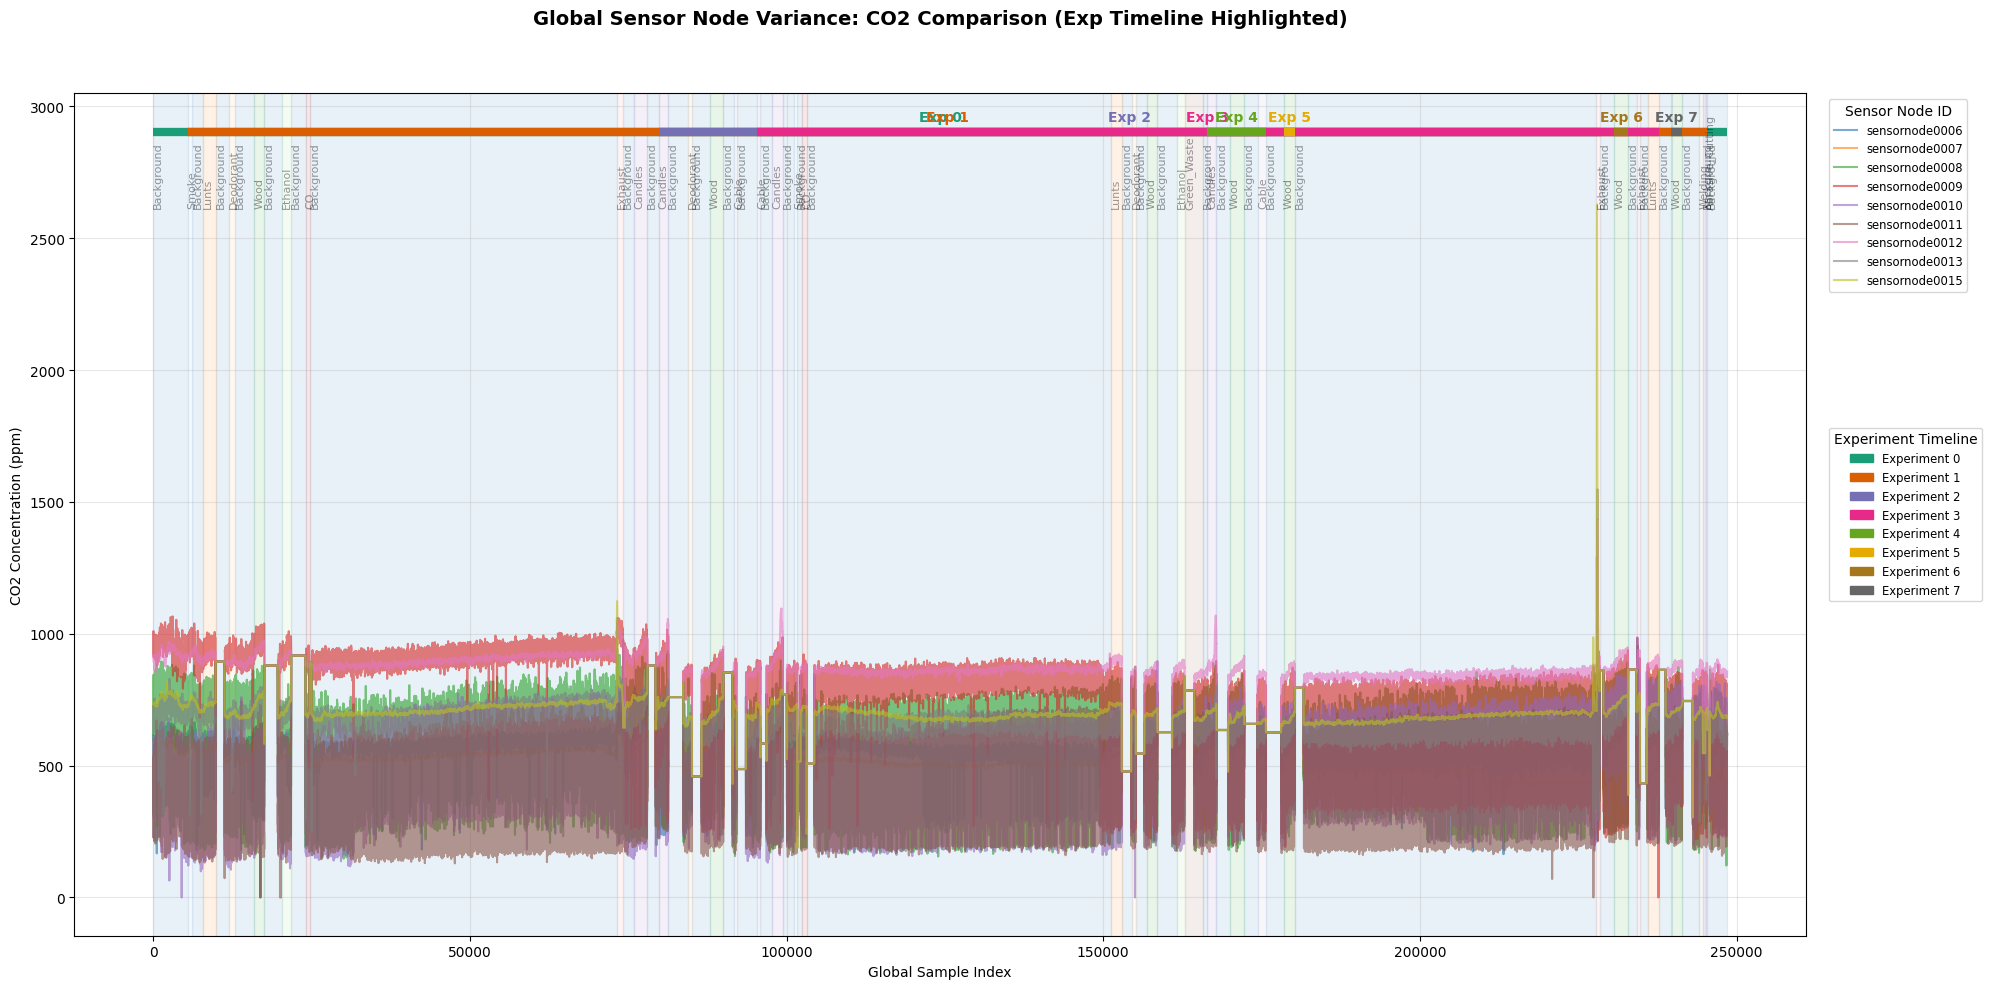

## 3 PyTorch Model Architecture: Lightweight Temporal Convolutional Networks (TCNs) Architecture for Sequence-classification:

To perform signal classification, we first define the model architecture in PyTorch before moving through the export pipeline.

- We choose the `TCN architecture` for this task, because of its efficient `dilated convolutions` which track (long-term dependency) pattern relationships across input sequences, by only looking at the most important related features at a time.

- This makes TCN both `accurate` and `lightweight` for streaming signal sequence data.

<br>

**Key Concepts for the TCN Model Architecture:**

- **Temporal Dependencies**: Using TCNs to capture signal trends over time, which is critical for distinguishing between a sudden fire and a gradual nuisance smoke accumulation.
- **Low-Latency Response**: In an industrial safety context, the model must trigger an alarm immediately upon detection, requiring the highly optimized runtime.

Example TCN detail and implementation:
https://pypi.org/project/pytorch-tcn/

Image below by Paul Krug. Illustrating effect of layers of Dilated Convolutions upon input features, and their effect on (embedding) output value predictions.

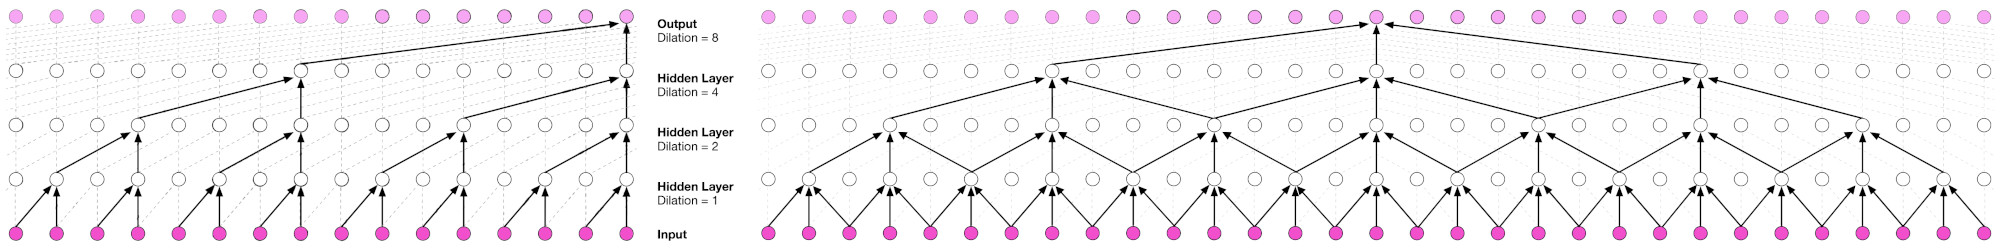

### 3.1 Model Code for TCN Architecture

> *Run code to proceed.*

In [ ]:
# @title
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score


# 1. Define the PyTorch TCN Structure
class TCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super(TCNBlock, self).__init__()
        # In PyTorch, causal padding for kernel k and dilation d is (k-1)*d
        self.padding = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               padding=self.padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               padding=self.padding, dilation=dilation)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.shortcut = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        res = F.relu(self.bn1(self.conv1(x)))
        # Slice off the 'future' padding to maintain causality
        res = res[:, :, :-self.padding]

        res = F.relu(self.bn2(self.conv2(res)))
        res = res[:, :, :-self.padding]

        shortcut = self.shortcut(x)
        return F.relu(res + shortcut)

class SimpleTCN(nn.Module):
    def __init__(self, num_features, num_classes=3):
        super(SimpleTCN, self).__init__()
        self.block1 = TCNBlock(num_features, 64, kernel_size=3, dilation=1)
        self.block2 = TCNBlock(64, 64, kernel_size=3, dilation=2)
        self.block3 = TCNBlock(64, 64, kernel_size=3, dilation=4)

        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(64, 32)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(32, num_classes)

    def forward(self, x):
        # PyTorch expects (Batch, Channels, Length)
        x = x.transpose(1, 2)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x).squeeze(-1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)

def create_tcn_model(num_features, num_classes=3):
    return SimpleTCN(num_features, num_classes)

# 1. Define Focal Loss for PyTorch
class PyTorchFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super(PyTorchFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

# 2. Define the training function
def train_model_f1(model, train_loader, val_loader, epochs=30, lr=0.001, device='cpu'):
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.004)
    criterion = PyTorchFocalLoss()

    # History tracking
    history = {'loss': [], 'f1': [], 'val_loss': [], 'val_f1': []}

    for epoch in range(epochs):
        model.train()
        train_loss, train_preds, train_targets = 0, [], []

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_preds.extend(outputs.argmax(1).cpu().numpy())
            train_targets.extend(batch_y.cpu().numpy())

        # Validation
        model.eval()
        val_loss, val_preds, val_targets = 0, [], []
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss += loss.item()
                val_preds.extend(outputs.argmax(1).cpu().numpy())
                val_targets.extend(batch_y.cpu().numpy())

        # Calculate Metrics
        train_f1 = f1_score(train_targets, train_preds, average='macro')
        val_f1 = f1_score(val_targets, val_preds, average='macro')

        # Log metrics
        history['loss'].append(train_loss / len(train_loader))
        history['f1'].append(train_f1)
        history['val_loss'].append(val_loss / len(val_loader))
        history['val_f1'].append(val_f1)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {history['loss'][-1]:.4f} - F1: {history['f1'][-1]:.4f} - Val Loss: {history['val_loss'][-1]:.4f} - Val F1: {history['val_f1'][-1]:.4f}")

    return history

### 3.2 Load Model Weights
- For a real-world use case, we load a set of pretrained weights or train the model's parameter weights via a task-specific dataset.
- We skip training here to focus strictly on deployment measurements.

In [ ]:
# Instantiate Model and Summary
num_features = 5
num_classes = 3
model = create_tcn_model( num_features, num_classes )
#print(model)

## 4 ExecuTorch Workflow

Transitioning from PyTorch to `ExecuTorch` involves exporting the network's graph and **`lowering`** it to a specific backend.


### 4.1 Export to XNNPACK Backend
- Create an exported model using a `backend` suitable for deployments to resource-constrained hardware and embedded systems.

**Key Concept (Lowering):**
- `Lowering` is the process of specializing a generic high-level computational graph into a low-level format that a specific hardware's instruction set or NPU driver understands.
- This is an essential step for high performance on edge devices.

In our case, we will evaluate the model within Python on the Google Colab server. For real deployments, you would execute the model via a low-level language library (e.g. C++) to load the compiled model file (.pte) and perform inference efficiently.

### 4.1.1 Export Model to "Lowered" XNNPACK backend ExecuTorch file:
- Create an exported model using a backend suitable for deployments to resource-constrained hardware and embedded systems.

In [ ]:
from executorch.exir import to_edge_transform_and_lower
from executorch.backends.xnnpack.partition.xnnpack_partitioner import XnnpackPartitioner
from torch.export import export
import torch

def export_to_executorch(model, example_inputs):
    """Exports a PyTorch model to an ExecuTorch program using XNNPACK."""
    model = model.eval()

    # Get weight dtype
    weight_dtype = str(next(model.parameters()).dtype).split('.')[-1]

    # Export to Program
    exported_program = export(model, example_inputs)

    # Lower to Edge and convert to ExecuTorch
    executorch_program = to_edge_transform_and_lower(
        exported_program,
        partitioner=[XnnpackPartitioner()],
    ).to_executorch()

    return executorch_program, weight_dtype

# Define inputs
# The SimpleTCN model expects (batch_size, sequence_length, num_features)
example_inputs = (torch.randn(1, 10, 5),)

# Call the function
executorch_program, weight_dtype = export_to_executorch(model, example_inputs)

## 5 Runtime Execution & Validation of the ExecuTorch model:

To move from a research environment (PyTorch) to an embedded environment (ExecuTorch), we must verify that the **lowered** model produces identical results.



### 5.1 Validation Steps
1. **Load Program**: Use the ExecuTorch runtime to pull the `.pte` binary into memory.
2. **Load Method**: Access the serialized execution graph (usually the `forward` method).
3. **Execute**: Run inference using the XNNPACK engine and compare results.

In [ ]:
pte_path = "tcn_xnnpack.pte"

with open(pte_path, "wb") as file:
    executorch_program.write_to_file(file) # Serializing into .pte file

In [ ]:
program = runtime.load_program(pte_path)
method = program.load_method("forward")

In [ ]:
t = torch.randn(1, 10, 5)
expected_output_shape = torch.Size([1, 3])

output = method.execute([t])
assert len(output) == 1, f"Unexpected output length {len(output)}"
assert output[0].size() == expected_output_shape, f"Unexpected output size {output[0].size()}"
print("PASS")

## 6 Benchmarking: Edge Performance Metrics

Deploying to the edge is about accuracy AND **resource efficiency**. In this section, we quantify exactly how much we have optimized the model for the target environment.

### 6.1 Theoretical Computational Complexity: Model FLOPs, MACs and Param Size:
First, we use the DeepSpeed profiler to determine the theoretical work (Floating Point Operations) our model performs per inference. This helps establish a baseline for hardware requirements.

In [ ]:
!uv pip install deepspeed

In [ ]:
from deepspeed.profiling.flops_profiler import get_model_profile
from deepspeed.accelerator import get_accelerator

with get_accelerator().device(0):
    batch_size = 1
    flops, macs, params = get_model_profile(model=model, # model
                                    input_shape=(batch_size, 10, 5), # input shape to the model. If specified, the model takes a tensor with this shape as the only positional argument.
                                    args=None, # list of positional arguments to the model.
                                    kwargs=None, # dictionary of keyword arguments to the model.
                                    print_profile=False, # prints the model graph with the measured profile attached to each module
                                    detailed=True, # print the detailed profile
                                    module_depth=-1, # depth into the nested modules, with -1 being the inner most modules
                                    top_modules=1, # the number of top modules to print aggregated profile
                                    warm_up=10, # the number of warm-ups before measuring the time of each module
                                    as_string=True, # print raw numbers (e.g. 1000) or as human-readable strings (e.g. 1k)
                                    output_file=None, # path to the output file. If None, the profiler prints to stdout.
                                    ignore_modules=None) # the list of modules to ignore in the profiling
flops, macs, params

### 6.2 Empirical Latency and Throughput Comparison
Next, we measure the real-world execution speed in milliseconds. By comparing PyTorch and ExecuTorch runtimes, we calculate the speedup factor and the total throughput (GFLOPS) achieved.

In [ ]:
import time, torch

def benchmark_executorch_ms(method, input_data, trials=20):
    # Warm-up
    method.execute([input_data])
    start = time.perf_counter()
    for _ in range(trials): method.execute([input_data])
    avg_ms = ((time.perf_counter() - start) / trials) * 1000
    return avg_ms

def benchmark_pytorch_ms(model, input_data, trials=20):
    model.eval()
    # Warm-up
    with torch.no_grad():
        model(input_data)
    with torch.no_grad():
        start = time.perf_counter()
        for _ in range(trials): model(input_data)
    avg_ms = ((time.perf_counter() - start) / trials) * 1000
    return avg_ms

# Run benchmarks
t = torch.randn(1, 10, 5)
num_trials = 150
time_ms_pytorch = benchmark_pytorch_ms(model, t, num_trials)
time_ms_inf = benchmark_executorch_ms(method, t, num_trials)

print(f"ExecuTorch Avg Inference Time ({num_trials} trials): {time_ms_inf:.3f} ms")
print(f"PyTorch Avg Inference Time ({num_trials} trials): {time_ms_pytorch:.3f} ms")
print(f"Speedup: {time_ms_pytorch / time_ms_inf:.2f}x")

### 6.3 Model File Sizes:

Next, we check the binary file size on disk. On edge devices, every kilobyte of Flash and RAM counts toward whether a model can physically run on the device.

The binary file size on disk is the primary proxy for the **static memory footprint**. If a target device has limited Flash/ROM, the .pte file size determines if the model can physically fit.

#### 6.3.1 Uncompressed native PyTorch file (PTH)

In [ ]:
import os
import torch

def export_pytorch_and_get_size(model, filename="model_pytorch.pth"):
    """Exports the PyTorch model to a .pth file and returns its size in bytes."""
    # Save the model state dict
    torch.save(model.state_dict(), filename)

    # Calculate size
    size_bytes = os.path.getsize(filename)
    return size_bytes

# Run the function
pth_filename = "model_pytorch.pth"
pth_size_bytes = export_pytorch_and_get_size(model, pth_filename)

print(f"PyTorch Model (.pth) size: {pth_size_bytes} bytes ({pth_size_bytes/1024:.2f} KB)")

#### 6.3.2 ExecuTorch file (PTE)

Note: While standard PyTorch files (above) are larger, the specialized lightweight interpreter in ExecuTorch significantly reduces runtime overhead in addition to its size on disk.

In [ ]:
import os

# The .pte file size represents the binary size of the program including weights
pte_size_bytes = os.path.getsize(pte_path)

print(f"ExecuTorch Program (.pte) size: {pte_size_bytes} bytes ({pte_size_bytes/1024:.2f} KB)")
print(f"PyTorch Model (.pth) size: {pth_size_bytes} bytes ({pth_size_bytes/1024:.2f} KB)")
reduction = (1 - (pte_size_bytes / pth_size_bytes)) * 100
print(f"\nSize Difference: {reduction:.2f}% change in footprint")

# HINT: If this model were still too large for a 256KB SRAM device,
# we would apply 'int8' quantization, which typically reduces size by ~4x.
print(f"\nInference weights size (approx): {pte_size_bytes} bytes")
print(f"Weight datatype: {weight_dtype}")

### 6.4 Model Performance Report

In [ ]:
import pandas as pd
import sys

def generate_model_performance_report(model, executorch_program,
                                      pth_size_bytes, pte_size_bytes,
                                      time_ms_pytorch, time_ms_inf,
                                      weight_dtype, params, flops):
    """Generates and displays a comprehensive performance comparison report."""

    # 1. Calculate dynamic differences
    size_pct = ((pte_size_bytes - pth_size_bytes) / pth_size_bytes) * 100
    latency_pct = ((time_ms_inf - time_ms_pytorch) / time_ms_pytorch) * 100

    performance_data = {
        "Metric": ["Precision", "Parameters", "FLOPs", "Model Size (KB)", "Inference Time (ms)"],
        "PyTorch (Source)": [
            weight_dtype,
            params,
            flops,
            f"{pth_size_bytes / 1024:.2f}",
            f"{time_ms_pytorch:.3f}"
        ],
        "ExecuTorch (.pte)": [
            weight_dtype,
            params,
            flops,
            f"{pte_size_bytes / 1024:.2f}",
            f"{time_ms_inf:.3f}"
        ],
        "Diff": [
            "--",
            "--",
            "--",
            f"{size_pct:+.2f}%",
            f"{latency_pct:+.2f}%"
        ]
    }

    # Display Report
    report_df = pd.DataFrame(performance_data)
    print("=== Model Performance Report ===")
    display(report_df)

    # 2. Print File Size Comparison (Memory Footprint)
    print(f"\n--- In-Memory (RAM) Footprint Change ---")
    print(f"PyTorch Model: {pth_size_bytes / 1024:.2f} KB")
    print(f"ExecuTorch Program: {pte_size_bytes / 1024:.2f} KB")
    mem_diff = ((pte_size_bytes - pth_size_bytes) / pth_size_bytes) * 100
    print(f"Difference: {mem_diff:+.2f}%")

    # 3. Throughput Analysis
    numeric_flops = float(flops.split()[0]) * 1e6
    et_gflops = (numeric_flops / (time_ms_inf / 1000)) / 1e9
    pt_gflops = (numeric_flops / (time_ms_pytorch / 1000)) / 1e9

    print(f"\n--- Throughput Change (on baseline hardware) ---")
    print(f"PyTorch: {pt_gflops:.4f} GFLOPS")
    print(f"ExecuTorch: {et_gflops:.4f} GFLOPS")
    print(f"Speedup Factor: {time_ms_pytorch / time_ms_inf:.2f}x faster")

# Execute the function
generate_model_performance_report(
    model,
    executorch_program,
    pth_size_bytes,
    pte_size_bytes,
    time_ms_pytorch,
    time_ms_inf,
    weight_dtype,
    params,
    flops
)

## 7 Environmental & Cross-Hardware Impact

In production, your model will run on hardware ranging from high-end GPUs to low-power MCUs.

Here, we use a library to estimate the viability and performance of running on different hardware. The technique estimates performance from the current hardware as a ratio to the other hardware.

- Ensure you have selected the `T4 GPU` runtime within in Google Colab.


In [ ]:
!uv pip install git+https://github.com/pmdscully/Edge_AI_Perf.git --upgrade


### 7.1 Energy and Carbon Estimation
Energy consumption is a function of both the thermal design power (hardware power or TDP) and inference latency. A high-throughput model (high GFLOPS) on a power-hungry GPU might actually consume more energy than a lower-throughput model on an MCU.



### 7.2 Hardware Constraint Analysis
**XNNPACK Efficiency:** XNNPACK achieves its speedups on mobile and embedded CPUs by bypassing the Python and utilizing highly optimized assembly kernels (like ARM NEON) to perform tensor operations.

In [ ]:
# FIX: Downgrade numpy to resolve the 'blas_supports_fpe' compatibility error with SciPy/Seaborn
# !uv pip install "numpy<2.0.0" "scipy>=1.10" --quiet
# import numpy as np

In [ ]:
from lib_edge_eval import fetch_edge_hardware_dataframe, Plotting

# ======= Calculate from Baseline: ========
df_final = fetch_edge_hardware_dataframe()
df_final

In [ ]:

Plotting.plot_hardware_comparisons(df_final)

Plotting.plot_hardware_comparisons(df_final,
                                   metrics=['Peak TOPS (INT8/NPU)', 'Peak TFLOPS (FP32/GPU)'],
                                   titles=['Peak TOPS (INT8/NPU)', 'Peak TFLOPS (FP32/GPU)']
                                   )

In [ ]:
from lib_edge_eval import calculate_edge_metrics, Plotting

# ======= Calculate from Baseline: ========
baseline_index = 8 # 8 = T4
baseline_memory_bytes = pte_size_bytes
baseline_time_ms = time_ms_inf
baseline_dtype = weight_dtype if weight_dtype in ['int8','fp8'] else ['int8','fp8'][1]

# Execution call
df_comparison = calculate_edge_metrics(
    df=df_final,
    baseline_idx=baseline_index,
    baseline_ms=baseline_time_ms,
    baseline_mem=baseline_memory_bytes,
    baseline_dtype=baseline_dtype
)

display(df_comparison.round(2))
Plotting.plot_comparison_metrics(df_comparison)


### 7.3 Reflection Question: Which hardware devices do you think are appropriate to run this model?

<details>
<summary><b>Click to reveal</b></summary>

Based on the **Model Performance Report** and **Hardware Constraint Analysis**, here is the breakdown of suitability:

*   **Appropriate (Ready for Deployment):**

    * **Hardware Feasibility**: The `🗸` indicator confirms whether our 270KB model fits within the specific RAM/Flash constraints of each device.
    *   **Microcontrollers (MCUs):** The **Ambiq Apollo 510** and **ESP32-S3** are excellent candidates as the ~270KB `.pte` file fits within their available memory (MRAM/PSRAM).
    *   **Single Board Computers (SBCs):** **Raspberry Pi 4 and 5** run this model with extreme ease, showing significant speedups compared to native PyTorch.
    *   **Edge AI Modules:** **NVIDIA Jetson** and high-end smartphones are technically appropriate but may be 'overkill' for such a lightweight model unless they are processing thousands of streams simultaneously.
    * **Environmental Impact (CO2-EQ)**:
      - High-performance GPUs like the **NVIDIA T4** (baseline) offer extreme speed but at the cost of higher power draw during inference.
      - When scaled to millions of inferences, the carbon footprint differences become a critical design constraint for sustainable AI.

*   **Conditional (Requires Optimization):**
    *   **Ultra-low-power NPUs:** The **Syntiant NDP200** has limited on-chip memory (640KB SRAM total). While our 270KB model *theoretically* fits, the remaining overhead for the runtime and activations would be very tight. For these devices, **int8 quantization** would be recommended to reduce the footprint to ~70KB.

*   **Efficiency Winner:**
    *   For an 'always-on' industrial fire sensor, the **Ambiq Apollo 510** or **ESP32-S3** are the most appropriate choices due to their balance of memory capacity and milliwatt-scale power consumption.

</details>

## 8. Learning Assessment and Exercises

To conclude this lab, complete the following exercises and the interactive quiz to verify your understanding of the TinyML deployment pipeline.

### 8.1 Quiz Questions:

- Find all of the correct (green) answers to each quiz question to complete the lab worksheet.


In [ ]:
!uv pip install jupyterquiz jupytercards

In [ ]:
from jupyterquiz import display_quiz

display_quiz('https://raw.githubusercontent.com/pmdscully/Edge_AI_Perf/refs/heads/main/learn/EdgeAI/lab01_pte_quiz.json')

### 8.3 Key Answers and Explanations

<details>
<summary><b>Click to reveal Explanations</b></summary>

#### Quiz Questions Rationale:

1.  **ExecuTorch Benefits**: The .pte format is superior for edge deployment because it uses a specialized lightweight interpreter and supports hardware delegates (like XNNPACK), allowing execution without a full Python environment.
2.  **XNNPACK Optimization**: Specifically optimizes neural network operators for **mobile and embedded CPUs** (ARM, x86) using manually-tuned assembly kernels.
3.  **TCN vs. CNN**: TCNs use **dilated causal convolutions** to capture temporal patterns in sensor signals (e.g., distinguishing smoke buildup from sudden fire) more efficiently than standard CNNs.
4.  **Memory Proxy**: The **.pte file size on disk** is our best proxy for the *Static Memory Footprint* (Flash/ROM). Dynamic memory is handled at runtime by the allocator.
5.  **Environmental Impact**: Carbon footprints are influenced by hardware **TDP**, **inference latency** (active processor time), and the initial **training energy**.
6.  **Throughput vs. Energy**: Higher GFLOPS does *not* always mean lower energy. A high-throughput model on a 100W GPU may consume more total Joules than a slow model on a 0.5W MCU.
7.  **Input Scaling**: Increasing sequence length (e.g., 10 to 50) increases **inference latency** because more sliding window convolutions must be computed, though the model parameter count remains constant.
8.  **Lowering**: The process of converting high-level PyTorch graphs into hardware-specific optimized formats (like XNNPACK delegates).
9.  **Quantization (int8)**: A critical technique for fitting models into small SRAM (e.g., 256KB), typically providing a **~4x reduction** in weight size.

</details>

```




```
<p style="text-align:center;">That's it! Congratulations! <br>
Save your worksheet as PDF (showing all of your Green Quiz Answers).
<br>
Now, let's return to the microcourse for the next step.
</p>